# RetailRocket EDA

Initial exploration of `events.csv` before feature engineering.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/events.csv')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df.head()

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106


In [4]:
df['visitorid'].value_counts()

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
           ... 
877104        1
1015187       1
1214670       1
648716        1
301110        1
Name: count, Length: 1407580, dtype: int64

In [2]:
print(df.dtypes)
print(df['event'].value_counts())
print(df.groupby('event').size())

timestamp                 int64
visitorid                 int64
event                    object
itemid                    int64
transactionid           float64
datetime         datetime64[ns]
dtype: object
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64
event
addtocart        69332
transaction      22457
view           2664312
dtype: int64


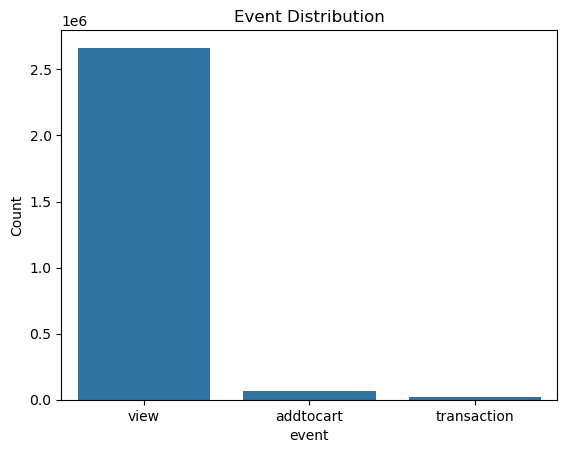

In [3]:
event_counts = df['event'].value_counts()
sns.barplot(x=event_counts.index, y=event_counts.values)
plt.title('Event Distribution')
plt.ylabel('Count')
plt.show()

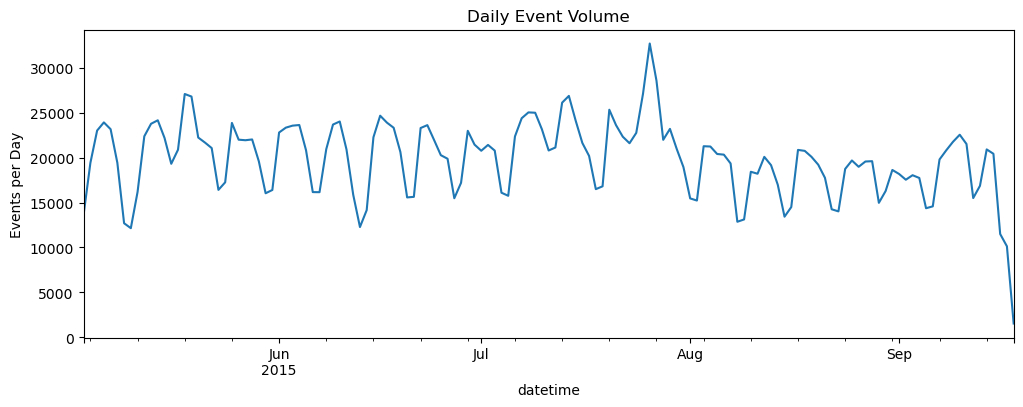

In [4]:
daily_events = df.set_index('datetime').resample('D').size()
daily_events.plot(figsize=(12, 4), title='Daily Event Volume')
plt.ylabel('Events per Day')
plt.show()